## ResNet on MNIST — 残差网络手写数字识别

### 为什么需要 ResNet？

普通的 CNN 堆叠到 20 层以上时会出现**网络退化**问题：层数越多，训练误差反而越大。

这不是过拟合——连训练集上的表现都在变差。根本原因是：深层网络的**梯度在反向传播中逐层衰减**，浅层参数几乎学不到东西。

ResNet 的核心思想非常优雅：给卷积层加一条「短路」（skip connection），让输入 `x` 直接加到输出上：

> **核心公式**：`output = F(x) + x`

这条短路带来两个关键好处：
1. **梯度高速公路** — 梯度可以通过 shortcut 直达浅层，解决了梯度消失
2. **恒等映射兜底** — 最坏情况下 `F(x)` 学到 0，`output = x`，至少不退化

本文将在 MNIST 上实现一个轻量 ResNet，帮助你理解残差网络的原理与实现。

## 1. 导入依赖与数据加载

ResNet 原论文使用 SGD + Momentum + CosineAnnealingLR，我们沿用这个配置。
MNIST 是 28×28 灰度图，输入形状为 `(N, 1, 28, 28)`。

In [10]:
# [1.1 导入依赖]
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# ==== 中文字体配置 ====
# matplotlib 默认不支持中文，需手动指定支持中文的字体
# 优先级：微软雅黑 > 黑体 > DejaVu Sans（英文回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')

设备: cuda


In [11]:
# [1.2 加载 MNIST 数据]
# MNIST 共 70000 张 28×28 灰度图，前 60000 为训练集，后 10000 为测试集
mnist = fetch_openml(
    name="mnist_784", version=1, as_frame=False,
    cache=True, data_home="../data"
)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# 转为 PyTorch 张量：添加通道维度 (N,1,28,28) 并归一化到 [0,1]
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) / 255.0
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1) / 255.0
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f'训练批次数: {len(train_loader)}, 测试批次数: {len(test_loader)}')

训练批次数: 938, 测试批次数: 157


## 2. 理解残差块（BasicBlock）

BasicBlock 是 ResNet 的基本构建单元。它包含两条路径：

```
           输入 x
             │
       ┌─────┴─────┐
       │           │
   Conv 3×3    短路(shortcut)
   BatchNorm       │
     ReLU     恒等映射 或
   Conv 3×3   1×1 卷积对齐
   BatchNorm       │
       │           │
       └─────┬─────┘
             ⊕  逐元素相加
             │
           ReLU
             │
         输出 out
```

### 短路连接的三种情况

| 情况 | 条件 | 短路方式 |
|------|------|----------|
| 恒等映射 | 尺寸、通道都不变 | `output = F(x) + x`，直接相加 |
| 通道适配 | 通道数变化 | 用 1×1 卷积将 x 投影到正确通道数 |
| 下采样 | stride > 1 | 用 stride=2 的 1×1 卷积同步缩小尺寸 |

> **为什么 Conv 中 `bias=False`？** 因为卷积后面紧跟着 BatchNorm，BN 会减去均值再除以标准差，卷积层的 bias 效果会被完全抵消，加了也白加。

In [12]:
# [2. BasicBlock 残差块]
class BasicBlock(nn.Module):
    """
    ResNet 基础残差块（适用于 ResNet-18/34）

    结构：
        主路 (main path):  Conv3×3 → BN → ReLU → Conv3×3 → BN
        短路 (shortcut):   恒等映射 或 1×1 卷积（当尺寸/通道不一致时）
        输出:               ReLU(主路 + 短路)

    参数说明：
        in_channels:  输入的通道数
        out_channels: 输出的通道数
        stride:       第一个卷积的步长（>1 时进行下采样）

    注意：
        expansion = 1 表示输出通道数 = out_channels
        （在 ResNet-50/101 的 Bottleneck 中 expansion=4，这里暂不涉及）
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # ==== 主路：两个 3×3 卷积 ====
        # 第一个卷积：可能改变通道数，可能做下采样（stride>1）
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 第二个卷积：保持尺寸不变（stride=1）、通道数不变
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # ==== 短路连接 ====
        # 当 stride>1 或通道数不一致时，用 1×1 卷积对齐尺寸和通道
        # 否则 shortcut 就是恒等映射（什么都不做）
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # 1. 计算短路分支（可能是恒等映射，也可能是 1×1 卷积）
        shortcut_out = self.shortcut(x)

        # 2. 主路前向传播：Conv → BN → ReLU → Conv → BN
        out = self.conv1(x)
        out = self.bn1(out)
        out = nn.ReLU()(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # 3. 残差连接：out = F(x) + x
        out = out + shortcut_out

        # 4. 加法后再过 ReLU
        out = nn.ReLU()(out)
        return out

## 3. 组装 ResNet 网络

### 整体架构

```
输入 (N, 1, 28, 28)
  │
  ▼
conv1: Conv 3×3 + BN + ReLU     ← 初始特征提取（28×28 → 28×28）
  │
  ▼
layer1: 2 个 BasicBlock, stride=1  [通道 32→32, 28×28 不变]
  │
  ▼
layer2: 2 个 BasicBlock, stride=2  [通道 32→64, 28×28 → 14×14]
  │
  ▼
layer3: 2 个 BasicBlock, stride=2  [通道 64→128, 14×14 → 7×7]
  │
  ▼
AdaptiveAvgPool2d((1,1))          ← 全局池化：7×7 → 1×1
  │
  ▼
Flatten → Linear(128, 10)         ← 分类头
  │
  ▼
输出: 10 个类别的 logits
```

### 关键设计说明

- **`_make_layer`**：将多个 BasicBlock 打包成一个层，第一个 block 负责通道/尺寸变换，后续 block 纯加深
- **为什么 layer1 不下采样？** MNIST 只有 28×28，第一层就下采样会丢失过多空间信息
- **为什么用 `AdaptiveAvgPool2d((1,1))`？** 无论特征图多大都池化到 1×1，比手动计算尺寸可靠。同时全局平均池化有正则化效果，减少过拟合
- **Kaiming 初始化**：`fan_out` 模式根据输出神经元数缩放方差，让 ReLU 后的激活值方差稳定，信号不会在前向中爆炸或消失
- **命名规则**：`num_blocks=[2,2,2]` → 总卷积层数 = 1(conv1) + 2×2×3(每层 2 个 block×2 个 conv) = 13 层卷积 + 1 层全连接 = **ResNet-14**

In [13]:
# [3. ResNet 网络主体]
class ResNet(nn.Module):
    """
    轻量 ResNet，为 MNIST 设计

    整体结构: conv1 → [layer1] → [layer2] → ... → avgpool → fc
    每层由多个 BasicBlock 串联而成

    可调参数:
        block:            残差块类型（BasicBlock 或 Bottleneck）
        num_blocks:       每层的 block 数量，如 [2,2,2] 表示 3 层各含 2 个 block
        num_classes:      分类类别数，MNIST 为 10
        initial_channels: 初始卷积层的输出通道数，默认 32
        channel_list:     每层输出通道列表，默认 [32, 64, 128]
                          注意：长度必须与 num_blocks 相等
    """
    def __init__(self, block, num_blocks, num_classes=10,
                 initial_channels=32, channel_list=None):
        super(ResNet, self).__init__()

        if channel_list is None:
            channel_list = [32, 64, 128]

        # 安全检查：channel_list 和 num_blocks 长度必须一致
        assert len(channel_list) == len(num_blocks), \
            f'channel_list 长度({len(channel_list)}) 与 num_blocks 长度({len(num_blocks)}) 不相等'

        self.in_channels = initial_channels   # 当前输入通道数（随 _make_layer 更新）
        self.num_layers = len(channel_list)    # 残差层数

        # ==== 初始卷积层 ====
        # 1 通道灰度图 → initial_channels 通道特征图，尺寸保持 28×28
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, initial_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(initial_channels),
            nn.ReLU()
        )

        # ==== 逐层构建残差层 ====
        # 以 channel_list=[32, 64, 128], num_blocks=[2,2,2] 为例：
        #   layer1: 2 blocks, 32→32, stride=1 → 输出 28×28×32
        #   layer2: 2 blocks, 32→64, stride=2 → 输出 14×14×64
        #   layer3: 2 blocks, 64→128, stride=2 → 输出 7×7×128
        for i, (ch, nb) in enumerate(zip(channel_list, num_blocks)):
            # 第一层不下采样（保留空间细节），后续层用 stride=2 缩小尺寸
            stride = 1 if i == 0 else 2
            layer = self._make_layer(block, ch, nb, stride=stride)
            # 动态命名：layer1, layer2, layer3...
            setattr(self, f'layer{i + 1}', layer)

        # ==== 全局平均池化 + 分类头 ====
        # AdaptiveAvgPool 将任意大小特征图自适应池化到 1×1，输出形状 = (N, channel_list[-1], 1, 1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # channel_list[-1] * block.expansion = 128 * 1 = 128 维 → 10 类
        self.fc = nn.Linear(channel_list[-1] * block.expansion, num_classes)

        # ==== Kaiming 权重初始化（ResNet 论文推荐）====
        # mode='fan_out'：根据输出神经元数量计算标准差，保证 ReLU 后信号方差稳定
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """
        用多个残差块构建一层网络

        参数:
            block:        残差块类型（如 BasicBlock）
            out_channels: 该层的输出通道数
            num_blocks:   该层包含的残差块数量
            stride:       该层第一个 block 的步长

        约定:
            第一个 block 负责通道变换和可能的降采样
            后续 block 通道和尺寸都不变，纯加深网络
        """
        layers = []
        # 第一个 block：stride 可能 >1（下采样），通道可能变化
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels   # 更新为新的通道数
        # 后续 block：stride=1，通道不变，尺寸不变
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)                          # (N,1,28,28) → (N,32,28,28)
        for i in range(1, self.num_layers + 1):
            x = getattr(self, f'layer{i}')(x)      # 逐层前向：layer1 → layer2 → layer3
        x = self.avgpool(x)                         # → (N,128,1,1)
        x = torch.flatten(x, 1)                     # → (N,128)
        x = self.fc(x)                              # → (N,10)
        return x

## 4. 实例化模型

默认配置是 ResNet-14：3 层，通道 `[32, 64, 128]`，每层 2 个 BasicBlock。
下面给出了调参示例，可以尝试更宽、更深、更多层的变体。

In [14]:
# [4. 模型实例化]
# 默认配置：ResNet-14（3 层，通道 [32, 64, 128]，每层 2 个 BasicBlock）
model = ResNet(BasicBlock, num_blocks=[2, 2, 2], num_classes=10).to(device)

# ==== 调参示例（取消注释即可尝试）====
# 更深: ResNet-20
# model = ResNet(BasicBlock, num_blocks=[3, 3, 3], num_classes=10).to(device)

# 更宽: ResNet-14-Wide
# model = ResNet(BasicBlock, num_blocks=[2, 2, 2], num_classes=10,
#                channel_list=[64, 128, 256]).to(device)

# 更多层: ResNet-26（4 层）
# model = ResNet(BasicBlock, num_blocks=[2, 2, 2, 2], num_classes=10,
#                channel_list=[32, 64, 128, 256]).to(device)
# ====================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')
print()
print(model)

总参数量: 696,042
可训练参数量: 696,042

ResNet(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), b

## 5. 损失函数与优化器

沿用 ResNet 原论文配置：
- **SGD + Momentum=0.9**：相比 Adam，SGD+Momentum 在 CNN 上通常泛化更好，不易过拟合
- **Weight Decay=1e-4**：L2 正则化，限制权重大小，防止过拟合
- **CosineAnnealingLR**：学习率按余弦曲线从 0.05 平滑衰减到 1e-4，比阶梯式衰减更稳定

In [15]:
# [5. 损失函数 + 优化器 + 学习率调度器]
# ResNet 原论文配置：SGD(lr=0.05) + Momentum(0.9) + weight_decay + CosineAnnealingLR

# ======== 超参数集中修改区 ========
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
T_MAX = 50          # CosineAnnealing 周期（设为总 epoch 数）
ETA_MIN = 1e-4      # 学习率下限（余弦曲线底部）
# =================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=T_MAX, eta_min=ETA_MIN
)
print(f'优化器: SGD(lr={LR}, momentum={MOMENTUM}) + CosineAnnealingLR(T_max={T_MAX})')

优化器: SGD(lr=0.05, momentum=0.9) + CosineAnnealingLR(T_max=50)


## 6. 训练与评估函数

| 训练模式 | `model.train()` | 梯度正常计算，BN 统计量实时更新 |
| 评估模式 | `model.eval()` + `torch.no_grad()` | 冻结梯度，冻结 BN 统计量，关闭 Dropout |

In [16]:
# [6. 训练/评估函数]
def train_one_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch，返回 (avg_loss, accuracy)"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # 标准训练五步
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """评估模型，返回 (avg_loss, accuracy)"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

## 7. 启动训练

训练 50 个 epoch。每个 epoch 后调用 `scheduler.step()` 让学习率沿余弦曲线平滑衰减。
自动保存最佳模型（`best.pth`）和周期性 checkpoint。

In [17]:
# [7. 训练循环]
EPOCHS = 50
CHECKPOINT_INTERVAL = 10   # 每 10 个 epoch 保存一次 checkpoint
SAVE_DIR = '../models/resnet'

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

best_test_acc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    # CosineAnnealingLR 每个 epoch 更新一次
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    # 保存最佳模型
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f'{SAVE_DIR}/best.pth')

    # 周期性保存 checkpoint
    if epoch % CHECKPOINT_INTERVAL == 0:
        torch.save(model.state_dict(), f'{SAVE_DIR}/epoch_{epoch}.pth')
        print(f'  [checkpoint] 已保存: resnet_epoch_{epoch}.pth')

    # 每 5 个 epoch 或第 1 个 epoch 打印进度
    if epoch % 5 == 0 or epoch == 1:
        print(
            f'Epoch [{epoch:3d}/{EPOCHS}] '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}'
        )

print(f'\n训练完成！最佳测试准确率: {best_test_acc:.4f} (Epoch {best_epoch})')

Epoch [  1/50] Train Loss: 0.1487 | Train Acc: 0.9503 | Test Loss:  0.0656 | Test Acc:  0.9775


KeyboardInterrupt: 

## 8. 训练曲线可视化

左侧 Loss 曲线观察收敛与过拟合情况，右侧 Accuracy 曲线用虚线标出最佳准确率。
ResNet 由于残差结构的隐式正则化效果，train-test gap 通常比同等深度的普通 CNN 更小。

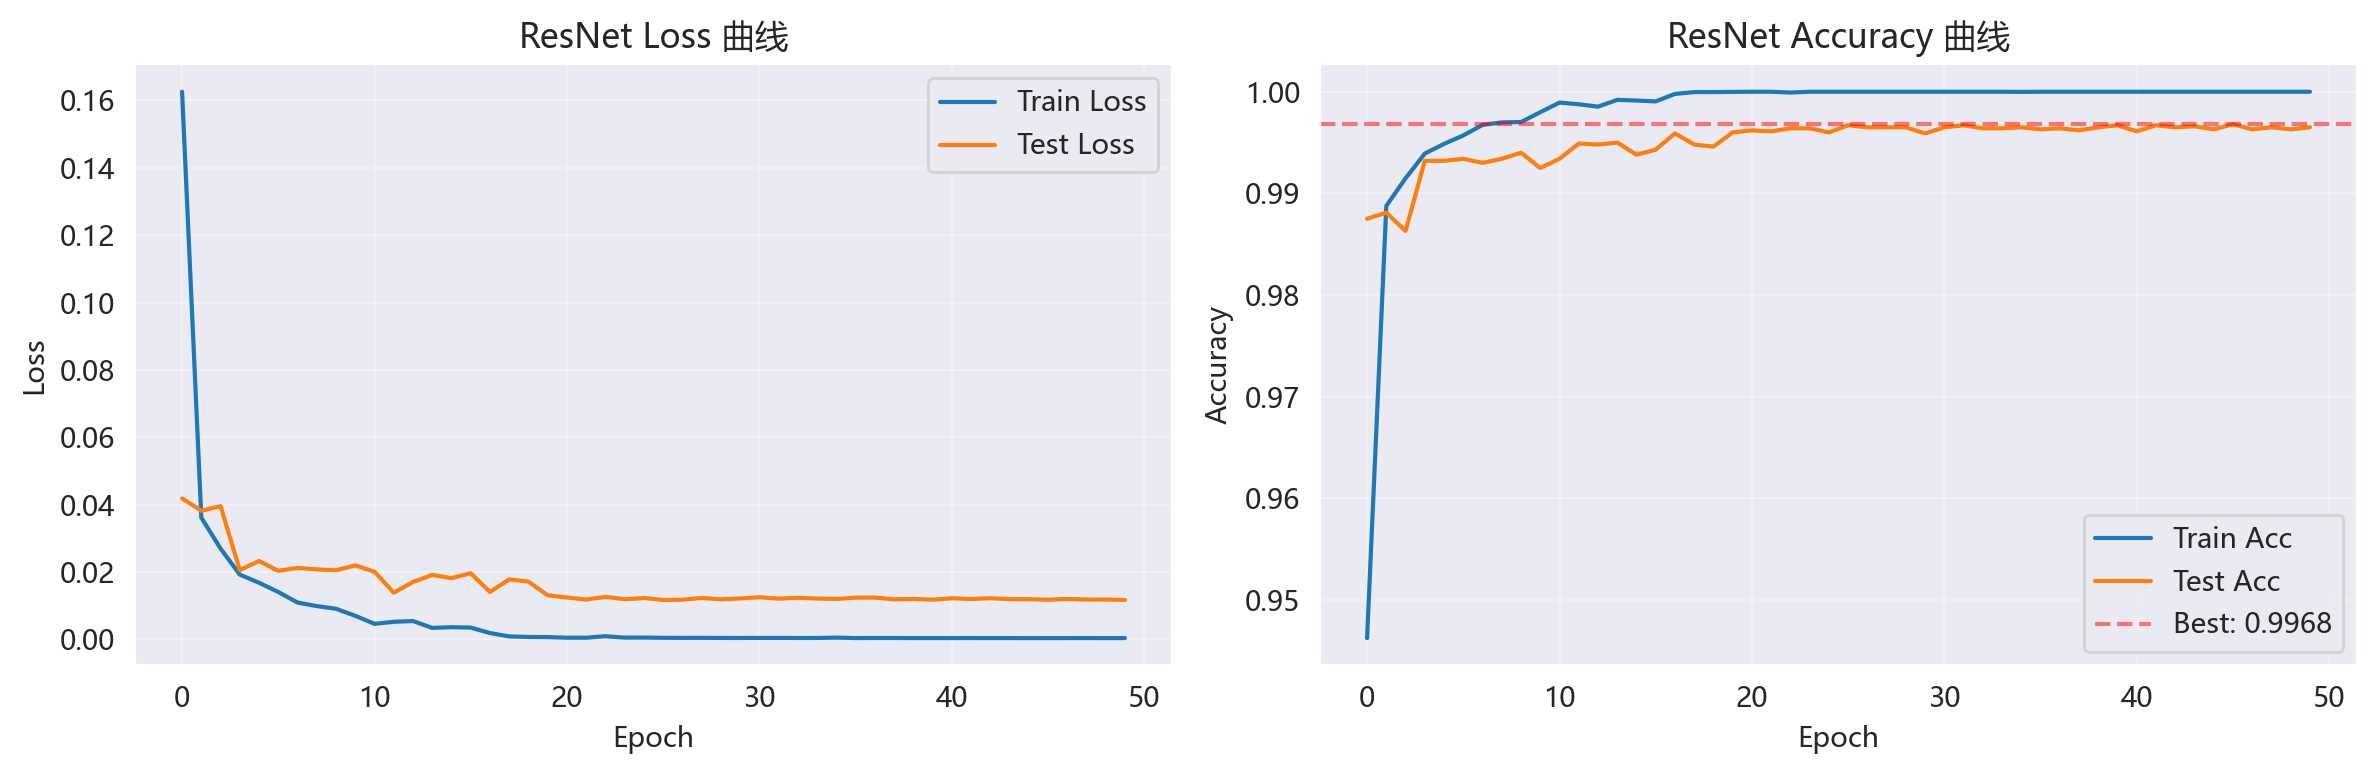

In [9]:
# [8. 训练曲线可视化]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：Loss 曲线
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ResNet Loss 曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：Accuracy 曲线
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['test_acc'], label='Test Acc')
axes[1].axhline(y=best_test_acc, color='r', linestyle='--', alpha=0.5,
                label=f'Best: {best_test_acc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ResNet Accuracy 曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 进一步学习

1. 修改 `channel_list` 和 `num_blocks`，观察参数量和精度的变化关系
2. 对比 [05_cnn_mnist.ipynb](05_cnn_mnist.ipynb) 的普通 CNN 结果，观察 train-test gap 差异
3. 阅读原论文 [Deep Residual Learning for Image Recognition (He et al., 2015)](https://arxiv.org/abs/1512.03385)